# Heart Rate Prediction from Wrist PPG

Goal: predict heart rate in BPM from wrist `BVP` / PPG and wrist `ACC` motion data.

Ground truth comes from ECG-derived labels stored in `data['label']`. ECG is only used to create labels, not as model input.

This notebook follows the steps from `ppgData.md`:

1. Load and inspect the dataset.
2. Plot the main signals.
3. Convert continuous BVP and ACC signals into 8-second windows with a 2-second shift.
4. Build a simple feature baseline.
5. Train classical ML baselines and report exact MAE/RMSE.
6. Train a neural sequence model.
7. Train an Attention / Transformer model and report exact MAE/RMSE.


## Step 1: Imports and Reproducibility

Run this first. If an import fails, install that package in the same Jupyter kernel environment.


In [31]:
import os
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

## Step 2: Paths and Dataset Constants

The synchronized `S*.pkl` files are the easiest starting point. They already contain wrist signals, chest signals, ECG-derived labels, activity labels, metadata, and subject IDs.


In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "HeartRate_Data"
print(DATA_DIR)
BVP_FS = 64       # wrist BVP / PPG sampling rate
ACC_FS = 32       # wrist accelerometer sampling rate
LABEL_SHIFT = 2   # labels are generated every 2 seconds
WINDOW_SEC = 8    # each HR label corresponds to an 8-second window

BVP_WINDOW = BVP_FS * WINDOW_SEC
ACC_WINDOW = ACC_FS * WINDOW_SEC
BVP_STEP = BVP_FS * LABEL_SHIFT
ACC_STEP = ACC_FS * LABEL_SHIFT

subject_files = sorted(DATA_DIR.glob("S*/S*.pkl"), key=lambda x: int(x.stem[1:]))
print(f"Found {len(subject_files)} subject pickle files")
for path in subject_files:
    print(path.relative_to(BASE_DIR))


/Users/ishananand/Desktop/Time-Series/SignalProcessing/PPG_FieldStudy
Found 15 subject pickle files
PPG_FieldStudy/S1/S1.pkl
PPG_FieldStudy/S2/S2.pkl
PPG_FieldStudy/S3/S3.pkl
PPG_FieldStudy/S4/S4.pkl
PPG_FieldStudy/S5/S5.pkl
PPG_FieldStudy/S6/S6.pkl
PPG_FieldStudy/S7/S7.pkl
PPG_FieldStudy/S8/S8.pkl
PPG_FieldStudy/S9/S9.pkl
PPG_FieldStudy/S10/S10.pkl
PPG_FieldStudy/S11/S11.pkl
PPG_FieldStudy/S12/S12.pkl
PPG_FieldStudy/S13/S13.pkl
PPG_FieldStudy/S14/S14.pkl
PPG_FieldStudy/S15/S15.pkl


## Step 3: Load One Subject

Use `encoding="latin1"`; otherwise many Python 2 pickles from this dataset raise a Unicode decode error.


In [26]:
def load_subject_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

s1_path = DATA_DIR / "S1" / "S1.pkl"
s1 = load_subject_pickle(s1_path)

print("Top-level keys:", s1.keys())
print("Subject:", s1["subject"])
print("Questionnaire:", s1["questionnaire"])
print("Labels shape:", s1["label"].shape)
print("Activity shape:", s1["activity"].shape)
print("R-peaks shape:", s1["rpeaks"].shape)
print("Wrist signals:")
for name, arr in s1["signal"]["wrist"].items():
    print(f"  {name:>4}: {arr.shape}")
print("Chest signals:")
for name, arr in s1["signal"]["chest"].items():
    print(f"  {name:>4}: {arr.shape}")


Top-level keys: dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])
Subject: S1
Questionnaire: {'WEIGHT': 78.0, 'Gender': ' m', 'AGE': 34, 'HEIGHT': 182.0, 'SKIN': 3, 'SPORT': 6}
Labels shape: (4603,)
Activity shape: (36848, 1)
R-peaks shape: (11431,)
Wrist signals:
   ACC: (294784, 3)
   BVP: (589568, 1)
   EDA: (36848, 1)
  TEMP: (36848, 1)
Chest signals:
   ACC: (6448400, 3)
   ECG: (6448400, 1)
   EMG: (6448400, 1)
   EDA: (6448400, 1)
  Temp: (6448400, 1)
  Resp: (6448400, 1)


## Step 4: Plot Signals and Labels

This helps verify that BVP, ACC, and HR labels are aligned enough to model. Motion-heavy regions usually make BVP noisier.


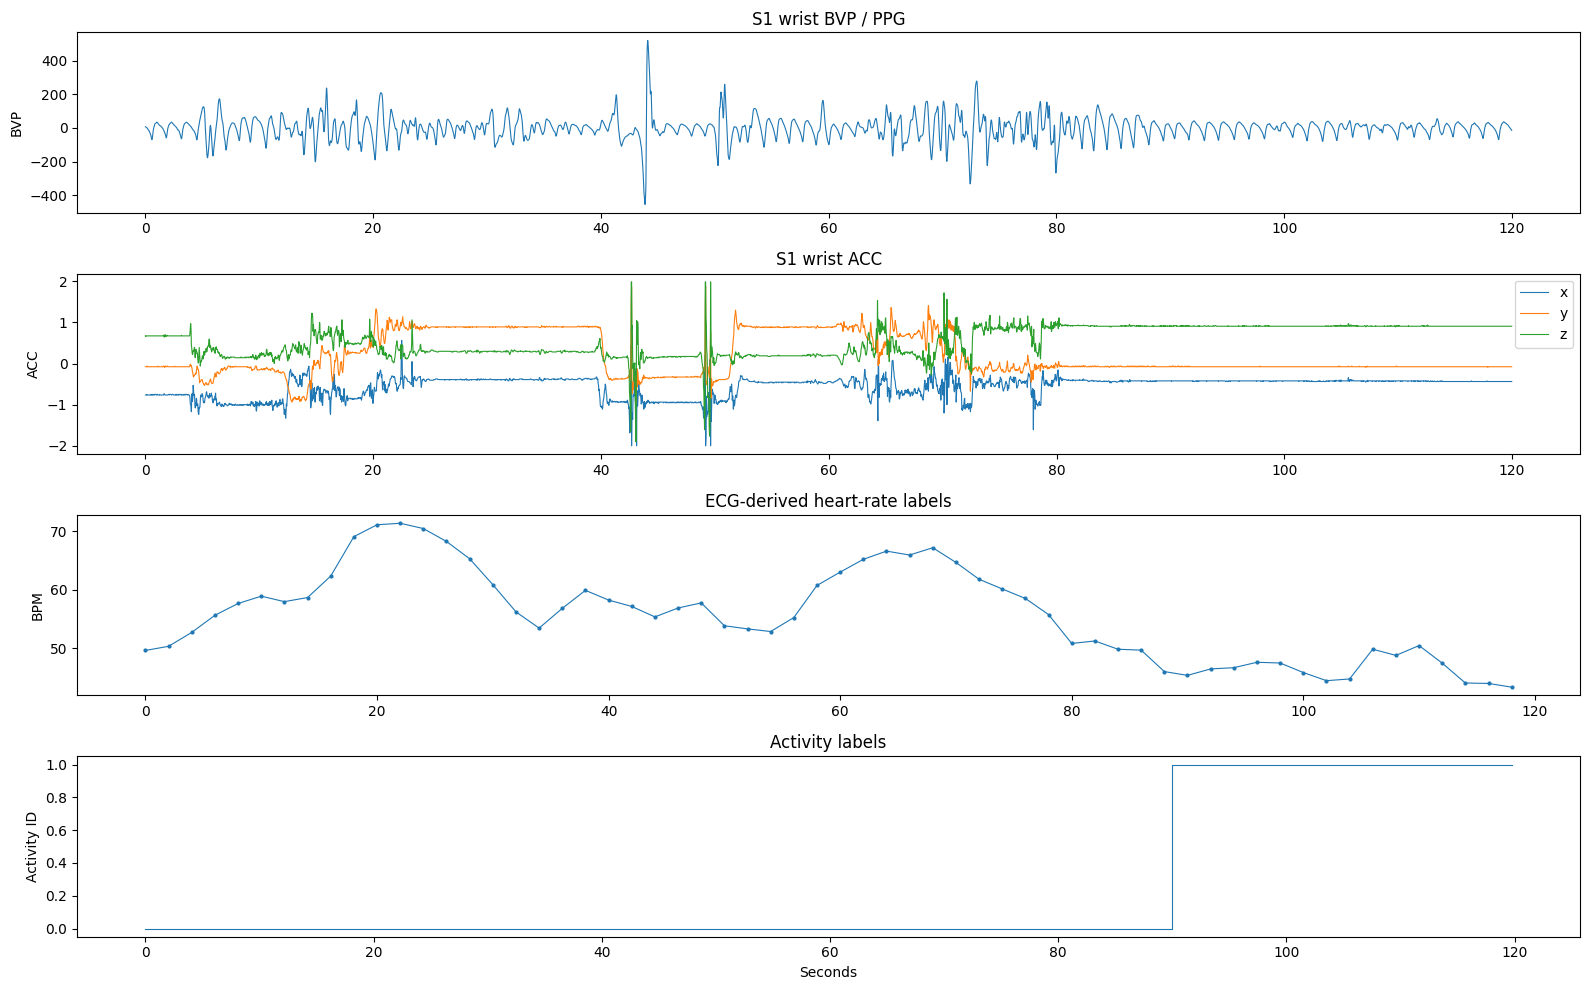

In [27]:
bvp = s1["signal"]["wrist"]["BVP"].squeeze()
acc = s1["signal"]["wrist"]["ACC"]
labels = s1["label"].squeeze()
activity = s1["activity"].squeeze()

seconds_to_plot = 120
bvp_n = seconds_to_plot * BVP_FS
acc_n = seconds_to_plot * ACC_FS
label_n = seconds_to_plot // LABEL_SHIFT
activity_n = seconds_to_plot * 4

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=False)

axes[0].plot(np.arange(bvp_n) / BVP_FS, bvp[:bvp_n], linewidth=0.8)
axes[0].set_title("S1 wrist BVP / PPG")
axes[0].set_ylabel("BVP")

axes[1].plot(np.arange(acc_n) / ACC_FS, acc[:acc_n, 0], label="x", linewidth=0.8)
axes[1].plot(np.arange(acc_n) / ACC_FS, acc[:acc_n, 1], label="y", linewidth=0.8)
axes[1].plot(np.arange(acc_n) / ACC_FS, acc[:acc_n, 2], label="z", linewidth=0.8)
axes[1].set_title("S1 wrist ACC")
axes[1].set_ylabel("ACC")
axes[1].legend()

axes[2].plot(np.arange(label_n) * LABEL_SHIFT, labels[:label_n], marker="o", markersize=2, linewidth=0.8)
axes[2].set_title("ECG-derived heart-rate labels")
axes[2].set_ylabel("BPM")

axes[3].step(np.arange(activity_n) / 4, activity[:activity_n], where="post", linewidth=0.8)
axes[3].set_title("Activity labels")
axes[3].set_ylabel("Activity ID")
axes[3].set_xlabel("Seconds")

plt.tight_layout()
plt.show()


## Step 5: Window BVP and ACC

Each training row corresponds to one HR label:

- BVP window length: `8 sec * 64 Hz = 512 samples`
- ACC window length: `8 sec * 32 Hz = 256 samples`
- Window shift: `2 sec`

For label `i`, use the BVP/ACC window starting at `i * 2 seconds`.


In [28]:
def make_windows_for_subject(data, subject_id):
    bvp = data["signal"]["wrist"]["BVP"].astype(np.float32).squeeze()
    acc = data["signal"]["wrist"]["ACC"].astype(np.float32)
    y = data["label"].astype(np.float32).squeeze()
    activity = data["activity"].astype(np.float32).squeeze()

    n_possible = min(
        len(y),
        (len(bvp) - BVP_WINDOW) // BVP_STEP + 1,
        (len(acc) - ACC_WINDOW) // ACC_STEP + 1,
    )

    bvp_windows = np.empty((n_possible, BVP_WINDOW), dtype=np.float32)
    acc_windows = np.empty((n_possible, ACC_WINDOW, 3), dtype=np.float32)
    activity_labels = np.empty(n_possible, dtype=np.int64)

    for i in range(n_possible):
        bvp_start = i * BVP_STEP
        acc_start = i * ACC_STEP
        activity_start = i * LABEL_SHIFT * 4
        activity_end = activity_start + WINDOW_SEC * 4

        bvp_windows[i] = bvp[bvp_start:bvp_start + BVP_WINDOW]
        acc_windows[i] = acc[acc_start:acc_start + ACC_WINDOW]

        # Most common activity during the 8-second window.
        act_window = activity[activity_start:activity_end].astype(int)
        activity_labels[i] = np.bincount(act_window).argmax() if len(act_window) else -1

    groups = np.repeat(subject_id, n_possible)
    return bvp_windows, acc_windows, y[:n_possible], activity_labels, groups

bvp_w, acc_w, y_s1, act_s1, groups_s1 = make_windows_for_subject(s1, "S1")
print("BVP windows:", bvp_w.shape)
print("ACC windows:", acc_w.shape)
print("Labels:", y_s1.shape)
print("Activities:", act_s1.shape)


BVP windows: (4603, 512)
ACC windows: (4603, 256, 3)
Labels: (4603,)
Activities: (4603,)


## Step 6: Feature Extraction Baseline

A feature baseline is useful because it trains quickly and gives us a number to beat before trying neural networks.


In [29]:
def dominant_frequency(x, fs, min_hz=0.7, max_hz=3.5):
    freqs, power = signal.welch(x, fs=fs, nperseg=min(len(x), 256))
    mask = (freqs >= min_hz) & (freqs <= max_hz)
    if not np.any(mask):
        return 0.0
    return float(freqs[mask][np.argmax(power[mask])])

def window_features(bvp_window, acc_window):
    feats = []

    # BVP time-domain features.
    feats.extend([
        np.mean(bvp_window),
        np.std(bvp_window),
        np.min(bvp_window),
        np.max(bvp_window),
        np.ptp(bvp_window),
        np.mean(np.abs(bvp_window)),
        np.sqrt(np.mean(bvp_window ** 2)),
        dominant_frequency(bvp_window, BVP_FS),
    ])

    # ACC features for x/y/z plus magnitude.
    acc_mag = np.linalg.norm(acc_window, axis=1)
    for arr in [acc_window[:, 0], acc_window[:, 1], acc_window[:, 2], acc_mag]:
        feats.extend([
            np.mean(arr),
            np.std(arr),
            np.min(arr),
            np.max(arr),
            np.ptp(arr),
            np.sqrt(np.mean(arr ** 2)),
        ])

    return np.asarray(feats, dtype=np.float32)

def build_feature_matrix(bvp_windows, acc_windows):
    X = np.vstack([
        window_features(bvp_windows[i], acc_windows[i])
        for i in range(len(bvp_windows))
    ])
    return X

X_s1_features = build_feature_matrix(bvp_w, acc_w)
print("Feature matrix:", X_s1_features.shape)
print("Target:", y_s1.shape)


Feature matrix: (4603, 32)
Target: (4603,)


## Step 7: S1 Baseline Models and Exact MAE

This split is within subject S1. It is easier than cross-subject evaluation because train and test come from the same person.


In [33]:
def regression_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE : {mae:.6f} BPM")
    print(f"  RMSE: {rmse:.6f} BPM")
    print(f"  R^2 : {r2:.6f}")
    return {"model": name, "mae": mae, "rmse": rmse, "r2": r2}

X_train, X_test, y_train, y_test = train_test_split(
    X_s1_features,
    y_s1,
    test_size=0.2,
    random_state=SEED,
    shuffle=False,
)

s1_results = []

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X_train, y_train)
s1_results.append(regression_report("S1 Ridge feature baseline", y_test, ridge.predict(X_test)))

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=2,
)
rf.fit(X_train, y_train)
s1_results.append(regression_report("S1 Random Forest feature baseline", y_test, rf.predict(X_test)))

gbr = GradientBoostingRegressor(random_state=SEED)
gbr.fit(X_train, y_train)
s1_results.append(regression_report("S1 Gradient Boosting feature baseline", y_test, gbr.predict(X_test)))

pd.DataFrame(s1_results).sort_values("mae")


S1 Ridge feature baseline
  MAE : 7.301616 BPM
  RMSE: 9.390172 BPM
  R^2 : 0.266506
S1 Random Forest feature baseline
  MAE : 9.439088 BPM
  RMSE: 11.411520 BPM
  R^2 : -0.083269
S1 Gradient Boosting feature baseline
  MAE : 7.396168 BPM
  RMSE: 9.401049 BPM
  R^2 : 0.264806


,model,mae,rmse,r2
0,S1 Ridge feature baseline,7.301616,9.390172,0.266506
2,S1 Gradient Boosting feature baseline,7.396168,9.401049,0.264806
1,S1 Random Forest feature baseline,9.439088,11.411520,-0.083269


## Step 8: Build the Full Multi-Subject Dataset

Now use all subjects. This is more realistic because the model must generalize across different people, skin tones, activities, and motion patterns.


In [34]:
all_bvp_windows = []
all_acc_windows = []
all_y = []
all_activity = []
all_groups = []

for path in subject_files:
    subject_id = path.stem
    data = load_subject_pickle(path)
    bvp_windows, acc_windows, y, activity_labels, groups = make_windows_for_subject(data, subject_id)
    all_bvp_windows.append(bvp_windows)
    all_acc_windows.append(acc_windows)
    all_y.append(y)
    all_activity.append(activity_labels)
    all_groups.append(groups)
    print(f"{subject_id}: {len(y)} windows")

BVP_ALL = np.concatenate(all_bvp_windows)
ACC_ALL = np.concatenate(all_acc_windows)
y_all = np.concatenate(all_y)
activity_all = np.concatenate(all_activity)
groups_all = np.concatenate(all_groups)

print("\nAll BVP windows:", BVP_ALL.shape)
print("All ACC windows:", ACC_ALL.shape)
print("All labels:", y_all.shape)
print("All groups:", groups_all.shape)


S1: 4603 windows
S2: 4099 windows
S3: 4367 windows
S4: 4572 windows
S5: 4649 windows
S6: 2622 windows
S7: 4668 windows
S8: 4037 windows
S9: 4277 windows
S10: 5321 windows
S11: 4521 windows
S12: 3954 windows
S13: 4565 windows
S14: 4476 windows
S15: 3966 windows

All BVP windows: (64697, 512)
All ACC windows: (64697, 256, 3)
All labels: (64697,)
All groups: (64697,)


## Step 9: Subject-Level Train/Test Split

This split keeps entire subjects out of training. It gives a much more honest estimate of real-world performance than mixing windows from the same subject into both train and test.


In [35]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(BVP_ALL, y_all, groups=groups_all))

print("Train subjects:", sorted(set(groups_all[train_idx])))
print("Test subjects:", sorted(set(groups_all[test_idx])))
print("Train windows:", len(train_idx))
print("Test windows:", len(test_idx))


Train subjects: [np.str_('S10'), np.str_('S11'), np.str_('S12'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S2'), np.str_('S3'), np.str_('S5'), np.str_('S7'), np.str_('S8'), np.str_('S9')]
Test subjects: [np.str_('S1'), np.str_('S4'), np.str_('S6')]
Train windows: 52900
Test windows: 11797


## Step 10: Multi-Subject Feature Baselines and Exact MAE

These are the main classical ML baseline numbers to compare against the neural models.


In [36]:
X_all_features = build_feature_matrix(BVP_ALL, ACC_ALL)
X_train_f = X_all_features[train_idx]
X_test_f = X_all_features[test_idx]
y_train_all = y_all[train_idx]
y_test_all = y_all[test_idx]

all_results = []

ridge_all = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
ridge_all.fit(X_train_f, y_train_all)
all_results.append(regression_report("All Subjects Ridge feature baseline", y_test_all, ridge_all.predict(X_test_f)))

rf_all = RandomForestRegressor(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=2,
)
rf_all.fit(X_train_f, y_train_all)
all_results.append(regression_report("All Subjects Random Forest feature baseline", y_test_all, rf_all.predict(X_test_f)))

gbr_all = GradientBoostingRegressor(random_state=SEED)
gbr_all.fit(X_train_f, y_train_all)
all_results.append(regression_report("All Subjects Gradient Boosting feature baseline", y_test_all, gbr_all.predict(X_test_f)))

pd.DataFrame(all_results).sort_values("mae")


All Subjects Ridge feature baseline
  MAE : 14.017837 BPM
  RMSE: 18.108141 BPM
  R^2 : 0.417087
All Subjects Random Forest feature baseline
  MAE : 11.659007 BPM
  RMSE: 16.094188 BPM
  R^2 : 0.539538
All Subjects Gradient Boosting feature baseline
  MAE : 11.870581 BPM
  RMSE: 15.884983 BPM
  R^2 : 0.551431


,model,mae,rmse,r2
1,All Subjects Random Forest feature baseline,11.659007,16.094188,0.539538
2,All Subjects Gradient Boosting feature baseline,11.870581,15.884983,0.551431
0,All Subjects Ridge feature baseline,14.017837,18.108141,0.417087


## Step 11: Prepare Raw Sequence Inputs for Neural Networks

The neural models use raw windows instead of hand-built features.

To combine BVP and ACC:

- Downsample BVP from 64 Hz to 32 Hz so it has 256 points.
- Concatenate BVP with ACC x/y/z.
- Final input shape per window: `(256 time steps, 4 channels)`.


In [37]:
def make_sequence_inputs(bvp_windows, acc_windows):
    # Downsample 512-point BVP windows to 256 points so they align with ACC.
    bvp_down = signal.resample(bvp_windows, ACC_WINDOW, axis=1).astype(np.float32)
    bvp_down = bvp_down[:, :, None]
    seq = np.concatenate([bvp_down, acc_windows.astype(np.float32)], axis=2)
    return seq

X_seq = make_sequence_inputs(BVP_ALL, ACC_ALL)

# Normalize channels using training data only.
channel_mean = X_seq[train_idx].mean(axis=(0, 1), keepdims=True)
channel_std = X_seq[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6
X_seq_norm = (X_seq - channel_mean) / channel_std

y_mean = y_all[train_idx].mean()
y_std = y_all[train_idx].std() + 1e-6
y_scaled = (y_all - y_mean) / y_std

print("Sequence input:", X_seq_norm.shape)
print("Channel mean:", channel_mean.squeeze())
print("Channel std:", channel_std.squeeze())


Sequence input: (64697, 256, 4)
Channel mean: [-2.4627094e-04 -5.3124517e-01  8.7450996e-02  3.4048277e-01]
Channel std: [83.454636   0.3539275  0.6380694  0.4000224]


## Step 12: PyTorch Dataset Helpers

The training loop reports MAE in real BPM, not scaled units.


In [38]:
class PPGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = PPGDataset(X_seq_norm[train_idx], y_scaled[train_idx])
test_ds = PPGDataset(X_seq_norm[test_idx], y_scaled[test_idx])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 414
Test batches: 47


In [39]:
def inverse_scale_hr(y_scaled_values):
    return y_scaled_values * y_std + y_mean

@torch.no_grad()
def evaluate_torch_model(model, loader, name):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch).detach().cpu().numpy().reshape(-1)
        target = y_batch.numpy().reshape(-1)
        preds.append(pred)
        targets.append(target)

    preds = inverse_scale_hr(np.concatenate(preds))
    targets = inverse_scale_hr(np.concatenate(targets))
    return regression_report(name, targets, preds)

def train_torch_model(model, train_loader, test_loader, epochs=20, lr=1e-3, patience=5, name="model"):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    best_mae = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        metrics = evaluate_torch_model(model, test_loader, name=f"{name} epoch {epoch}")
        mae = metrics["mae"]
        print(f"Epoch {epoch:02d} | train MSE: {np.mean(train_losses):.6f} | test MAE: {mae:.6f} BPM")

        if mae < best_mae:
            best_mae = mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping after {epoch} epochs")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_metrics = evaluate_torch_model(model, test_loader, name=f"BEST {name}")
    return model, final_metrics


## Step 13: 1D CNN Baseline

This neural baseline should be faster than the Transformer and often performs well on physiological windows.


In [40]:
class CNNRegressor(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: batch, time, channels -> batch, channels, time
        x = x.transpose(1, 2)
        x = self.net(x)
        return self.head(x)

cnn = CNNRegressor(in_channels=4)
cnn, cnn_metrics = train_torch_model(
    cnn,
    train_loader,
    test_loader,
    epochs=25,
    lr=1e-3,
    patience=6,
    name="CNN raw-window model",
)
all_results.append(cnn_metrics)


CNN raw-window model epoch 1
  MAE : 10.318188 BPM
  RMSE: 13.896937 BPM
  R^2 : 0.656684
Epoch 01 | train MSE: 0.387684 | test MAE: 10.318188 BPM
CNN raw-window model epoch 2
  MAE : 8.518641 BPM
  RMSE: 12.115510 BPM
  R^2 : 0.739061
Epoch 02 | train MSE: 0.214318 | test MAE: 8.518641 BPM
CNN raw-window model epoch 3
  MAE : 8.218964 BPM
  RMSE: 11.992429 BPM
  R^2 : 0.744336
Epoch 03 | train MSE: 0.166889 | test MAE: 8.218964 BPM
CNN raw-window model epoch 4
  MAE : 8.971403 BPM
  RMSE: 13.038347 BPM
  R^2 : 0.697796
Epoch 04 | train MSE: 0.148633 | test MAE: 8.971403 BPM
CNN raw-window model epoch 5
  MAE : 7.932765 BPM
  RMSE: 11.750372 BPM
  R^2 : 0.754552
Epoch 05 | train MSE: 0.134326 | test MAE: 7.932765 BPM
CNN raw-window model epoch 6
  MAE : 8.287361 BPM
  RMSE: 11.328939 BPM
  R^2 : 0.771843
Epoch 06 | train MSE: 0.122047 | test MAE: 8.287361 BPM
CNN raw-window model epoch 7
  MAE : 7.344917 BPM
  RMSE: 10.629746 BPM
  R^2 : 0.799136
Epoch 07 | train MSE: 0.113629 | test M

## Step 14: LSTM Model

The LSTM reads the same raw sequence as the CNN:

```text
[BVP_downsampled, ACC_x, ACC_y, ACC_z]
```

It is useful because it processes the 8-second window as an ordered time series and can learn temporal patterns across the window.


In [41]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=96, num_layers=2, dropout=0.2, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out_dim),
            nn.Linear(lstm_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        last_step = output[:, -1, :]
        return self.head(last_step)

lstm = LSTMRegressor(
    input_dim=4,
    hidden_dim=96,
    num_layers=2,
    dropout=0.2,
    bidirectional=True,
)

lstm, lstm_metrics = train_torch_model(
    lstm,
    train_loader,
    test_loader,
    epochs=30,
    lr=7e-4,
    patience=7,
    name="LSTM raw-window model",
)
all_results.append(lstm_metrics)


LSTM raw-window model epoch 1
  MAE : 16.539244 BPM
  RMSE: 21.624897 BPM
  R^2 : 0.168688
Epoch 01 | train MSE: 0.845067 | test MAE: 16.539244 BPM
LSTM raw-window model epoch 2
  MAE : 16.664288 BPM
  RMSE: 22.887308 BPM
  R^2 : 0.068795
Epoch 02 | train MSE: 0.819780 | test MAE: 16.664288 BPM
LSTM raw-window model epoch 3
  MAE : 15.882376 BPM
  RMSE: 20.837582 BPM
  R^2 : 0.228119
Epoch 03 | train MSE: 0.782655 | test MAE: 15.882376 BPM
LSTM raw-window model epoch 4
  MAE : 15.973391 BPM
  RMSE: 20.465506 BPM
  R^2 : 0.255438
Epoch 04 | train MSE: 0.740002 | test MAE: 15.973391 BPM
LSTM raw-window model epoch 5
  MAE : 17.036592 BPM
  RMSE: 22.907467 BPM
  R^2 : 0.067154
Epoch 05 | train MSE: 0.766733 | test MAE: 17.036592 BPM
LSTM raw-window model epoch 6
  MAE : 16.421995 BPM
  RMSE: 21.179554 BPM
  R^2 : 0.202576
Epoch 06 | train MSE: 0.787477 | test MAE: 16.421995 BPM
LSTM raw-window model epoch 7
  MAE : 17.034754 BPM
  RMSE: 21.300333 BPM
  R^2 : 0.193455
Epoch 07 | train MSE:

## Step 15: Attention / Transformer Model

This model uses self-attention over the 256 time steps. It receives the same 4-channel raw sequence:

```text
[BVP_downsampled, ACC_x, ACC_y, ACC_z]
```

The final MAE printed by `BEST Transformer attention model` is the exact Transformer MAE for this split and seed.


In [43]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim=4, d_model=64, nhead=4, num_layers=3, dim_feedforward=128, dropout=0.15):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.position = PositionalEncoding(d_model=d_model, max_len=ACC_WINDOW)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attention_pool = nn.Sequential(
            nn.Linear(d_model, 1),
            nn.Softmax(dim=1),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.position(x)
        encoded = self.encoder(x)
        weights = self.attention_pool(encoded)
        pooled = torch.sum(encoded * weights, dim=1)
        return self.head(pooled)

transformer = TransformerRegressor(
    input_dim=4,
    d_model=64,
    nhead=4,
    num_layers=3,
    dim_feedforward=128,
    dropout=0.15,
)

transformer, transformer_metrics = train_torch_model(
    transformer,
    train_loader,
    test_loader,
    epochs=35,
    lr=5e-4,
    patience=7,
    name="Transformer attention model",
)
all_results.append(transformer_metrics)


Transformer attention model epoch 1
  MAE : 15.791575 BPM
  RMSE: 20.142687 BPM
  R^2 : 0.278742
Epoch 01 | train MSE: 0.646259 | test MAE: 15.791575 BPM
Transformer attention model epoch 2
  MAE : 15.864627 BPM
  RMSE: 19.709328 BPM
  R^2 : 0.309443
Epoch 02 | train MSE: 0.513522 | test MAE: 15.864627 BPM
Transformer attention model epoch 3
  MAE : 15.542042 BPM
  RMSE: 19.662088 BPM
  R^2 : 0.312750
Epoch 03 | train MSE: 0.465619 | test MAE: 15.542042 BPM
Transformer attention model epoch 4
  MAE : 15.546638 BPM
  RMSE: 19.598818 BPM
  R^2 : 0.317165
Epoch 04 | train MSE: 0.437349 | test MAE: 15.546638 BPM
Transformer attention model epoch 5
  MAE : 16.137463 BPM
  RMSE: 20.226789 BPM
  R^2 : 0.272707
Epoch 05 | train MSE: 0.416482 | test MAE: 16.137463 BPM
Transformer attention model epoch 6
  MAE : 15.093665 BPM
  RMSE: 19.396036 BPM
  R^2 : 0.331222
Epoch 06 | train MSE: 0.391026 | test MAE: 15.093665 BPM
Transformer attention model epoch 7
  MAE : 15.538254 BPM
  RMSE: 19.647945 

KeyboardInterrupt: 

## Step 16: Normal Neural Network / MLP

This is a standard feed-forward neural network. Unlike CNN, LSTM, and Transformer, it does not read the raw signal as a sequence.

Instead, it uses the engineered feature matrix from Step 10:

```text
window features -> dense layers -> predicted BPM
```

This gives a neural-network version of the classical ML baseline.


In [44]:
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Normalize feature inputs using training data only.
feature_mean = X_train_f.mean(axis=0, keepdims=True)
feature_std = X_train_f.std(axis=0, keepdims=True) + 1e-6
X_train_mlp = (X_train_f - feature_mean) / feature_std
X_test_mlp = (X_test_f - feature_mean) / feature_std

# Reuse the same HR target scaling used by the sequence neural models.
y_train_mlp = (y_train_all - y_mean) / y_std
y_test_mlp = (y_test_all - y_mean) / y_std

mlp_train_ds = FeatureDataset(X_train_mlp, y_train_mlp)
mlp_test_ds = FeatureDataset(X_test_mlp, y_test_mlp)

mlp_train_loader = DataLoader(mlp_train_ds, batch_size=256, shuffle=True, drop_last=False)
mlp_test_loader = DataLoader(mlp_test_ds, batch_size=512, shuffle=False, drop_last=False)

print("MLP train features:", X_train_mlp.shape)
print("MLP test features:", X_test_mlp.shape)


MLP train features: (52900, 32)
MLP test features: (11797, 32)


In [45]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

mlp = MLPRegressor(input_dim=X_train_mlp.shape[1])
mlp, mlp_metrics = train_torch_model(
    mlp,
    mlp_train_loader,
    mlp_test_loader,
    epochs=40,
    lr=1e-3,
    patience=8,
    name="MLP feature neural network",
)
all_results.append(mlp_metrics)


MLP feature neural network epoch 1
  MAE : 12.677588 BPM
  RMSE: 16.509003 BPM
  R^2 : 0.515496
Epoch 01 | train MSE: 0.523533 | test MAE: 12.677588 BPM
MLP feature neural network epoch 2
  MAE : 11.859610 BPM
  RMSE: 15.901361 BPM
  R^2 : 0.550506
Epoch 02 | train MSE: 0.416419 | test MAE: 11.859610 BPM
MLP feature neural network epoch 3
  MAE : 12.034013 BPM
  RMSE: 16.121994 BPM
  R^2 : 0.537945
Epoch 03 | train MSE: 0.378811 | test MAE: 12.034013 BPM
MLP feature neural network epoch 4
  MAE : 11.867670 BPM
  RMSE: 15.970566 BPM
  R^2 : 0.546585
Epoch 04 | train MSE: 0.359841 | test MAE: 11.867670 BPM
MLP feature neural network epoch 5
  MAE : 11.765697 BPM
  RMSE: 15.830045 BPM
  R^2 : 0.554528
Epoch 05 | train MSE: 0.345299 | test MAE: 11.765697 BPM
MLP feature neural network epoch 6
  MAE : 11.957456 BPM
  RMSE: 16.023232 BPM
  R^2 : 0.543589
Epoch 06 | train MSE: 0.333565 | test MAE: 11.957456 BPM
MLP feature neural network epoch 7
  MAE : 11.714513 BPM
  RMSE: 15.655599 BPM
  R

## Step 17: Final Exact MAE Table

This table is the result summary. Re-run the notebook from top to bottom whenever you change the split, features, model, or seed.


In [46]:
results_df = pd.DataFrame(all_results).sort_values("mae").reset_index(drop=True)
results_df


,model,mae,rmse,r2
0,BEST CNN raw-window model,6.648082,10.396937,0.807838
1,BEST MLP feature neural network,11.365269,15.539139,0.570751
2,All Subjects Random Forest feature baseline,11.659007,16.094188,0.539538
3,All Subjects Gradient Boosting feature baseline,11.870581,15.884983,0.551431
4,All Subjects Ridge feature baseline,14.017837,18.108141,0.417087
5,BEST LSTM raw-window model,15.882376,20.837582,0.228119


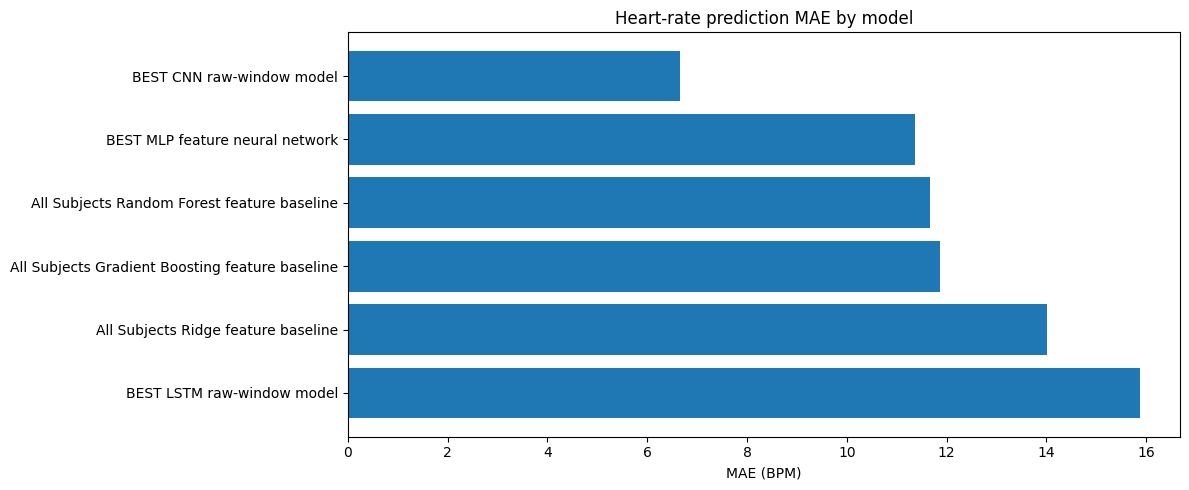

In [47]:
plt.figure(figsize=(12, 5))
plt.barh(results_df["model"], results_df["mae"])
plt.xlabel("MAE (BPM)")
plt.title("Heart-rate prediction MAE by model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Step 18: What to Try Next

Once the full notebook runs, improve the best model by trying:

- Leave-one-subject-out validation instead of one random subject split.
- More signal-quality features such as SNR, perfusion index approximations, and peak consistency.
- Activity-aware modeling: train one model per activity or add activity as an input feature.
- Stronger Transformer settings: larger `d_model`, more layers, longer training, learning-rate scheduler.
- Compare against a pure BVP model to measure how much ACC helps.
